# 7b - Normalize TopN Videos (FFmpeg CPU)

Normalizes video files from the metadata produced by notebook 06 using FFmpeg on CPU:
- input: `merged_datasets/universal_metadata_topn_classes.csv`
- keeps original FPS (or forces 30 FPS if configured)
- resizes to `224x224`
- converts to grayscale
- saves new MP4s and a metadata CSV

A temporary benchmark cell for 100 videos is included and can be deleted later.

In [6]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from fractions import Fraction
from pathlib import Path
from typing import Dict, Any
import json
import shutil
import subprocess
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.style.use("ggplot")

ffmpeg_path = shutil.which("ffmpeg")
ffprobe_path = shutil.which("ffprobe")
print("ffmpeg on PATH:", ffmpeg_path if ffmpeg_path else "NOT FOUND")
print("ffprobe on PATH:", ffprobe_path if ffprobe_path else "NOT FOUND")

ffmpeg on PATH: C:\Users\iwo\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1-full_build\bin\ffmpeg.EXE
ffprobe on PATH: C:\Users\iwo\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1-full_build\bin\ffprobe.EXE


In [ ]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

INPUT_CSV = PROJECT_ROOT / "merged_datasets" / "universal_metadata_topn_classes.csv"
OUTPUT_DIR = PROJECT_ROOT / "normalized_videos" / "topn_keepfps_224_gray"
OUTPUT_METADATA_CSV = PROJECT_ROOT / "merged_datasets" / "universal_metadata_topn_videos_normalized.csv"

TARGET_SIZE = (224, 224)
KEEP_ORIGINAL_FPS = True
COLOR_MODE = "grayscale"
OVERWRITE = True
MAX_WORKERS = 4
GENERATE_VIDEOS = True

MAX_VIDEOS = None
SHUFFLE_BEFORE_LIMIT = True
RANDOM_SEED = 42

FFMPEG_BIN = "ffmpeg"
FFPROBE_BIN = "ffprobe"
VIDEO_CODEC = "libx264"
X264_PRESET = "veryfast"
X264_CRF = 23
PIX_FMT = "yuv420p"
OUTPUT_FILE_EXT = ".mp4"
LOGLEVEL = "error"

RUN_BENCHMARK_100 = True
BENCHMARK_SIZE = 100
BENCHMARK_OUTPUT_DIR = PROJECT_ROOT / "normalized_videos" / "topn_keepfps_224_gray_benchmark100"

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_CSV}. Run notebook 06 first.")

print("INPUT_CSV:", INPUT_CSV)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("OUTPUT_METADATA_CSV:", OUTPUT_METADATA_CSV)
print("MAX_VIDEOS:", MAX_VIDEOS)
print("MAX_WORKERS:", MAX_WORKERS)
print("GENERATE_VIDEOS:", GENERATE_VIDEOS)
print("FFMPEG_BIN:", FFMPEG_BIN)
print("FFPROBE_BIN:", FFPROBE_BIN)
print("VIDEO_CODEC:", VIDEO_CODEC)
print("X264_PRESET:", X264_PRESET)
print("RUN_BENCHMARK_100:", RUN_BENCHMARK_100)

INPUT_CSV: D:\college\sem_mag_1\szum\merged_datasets\universal_metadata_topn_classes.csv
OUTPUT_DIR: D:\college\sem_mag_1\szum\normalized_videos\topn_keepfps_224_gray
OUTPUT_METADATA_CSV: D:\college\sem_mag_1\szum\merged_datasets\universal_metadata_topn_videos_normalized.csv
MAX_VIDEOS: None
MAX_WORKERS: 4
GENERATE_VIDEOS: True
FFMPEG_BIN: ffmpeg
FFPROBE_BIN: ffprobe
VIDEO_CODEC: libx264
X264_PRESET: veryfast
RUN_BENCHMARK_100: False


In [8]:
def validate_input_df(df: pd.DataFrame) -> None:
    required_cols = ["video_path", "label"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def resolve_video_path(raw_path: str, project_root: Path) -> Path:
    p = Path(raw_path)
    if p.is_absolute():
        return p
    return project_root / p


def to_repo_path(absolute_path: Path, project_root: Path) -> str:
    try:
        return str(absolute_path.relative_to(project_root)).replace("\\", "/")
    except ValueError:
        return str(absolute_path).replace("\\", "/")


def _safe_float(value: Any) -> float:
    try:
        return float(value)
    except Exception:
        return np.nan


def _parse_fraction(value: Any) -> float:
    text = str(value).strip() if value is not None else ""
    if not text or text.lower() in {"n/a", "nan", "none", "0/0"}:
        return np.nan
    try:
        return float(Fraction(text))
    except Exception:
        return np.nan


def _pick_valid_fps(probed_fps: float, metadata_fps: Any) -> float:
    if np.isfinite(probed_fps) and probed_fps > 1e-6:
        return float(probed_fps)
    fps_meta = _safe_float(metadata_fps)
    if np.isfinite(fps_meta) and fps_meta > 1e-6:
        return float(fps_meta)
    return 30.0


def _sanitize_error(text: str, max_len: int = 600) -> str:
    cleaned = (text or "").strip().replace("\r", " ").replace("\n", " | ")
    if not cleaned:
        return "Unknown error"
    if len(cleaned) <= max_len:
        return cleaned
    return cleaned[: max_len - 3] + "..."


def ffprobe_video(path: Path, ffprobe_bin: str) -> Dict[str, Any]:
    cmd = [
        ffprobe_bin,
        "-v",
        "error",
        "-print_format",
        "json",
        "-show_streams",
        "-show_format",
        str(path),
    ]
    completed = subprocess.run(cmd, capture_output=True, text=True)
    if completed.returncode != 0:
        message = completed.stderr.strip() or completed.stdout.strip()
        raise RuntimeError(message or f"ffprobe failed with exit code {completed.returncode}")

    try:
        payload = json.loads(completed.stdout or "{}")
    except json.JSONDecodeError as exc:
        raise RuntimeError(f"Invalid ffprobe JSON output: {exc}") from exc

    streams = payload.get("streams", [])
    video_stream = next((s for s in streams if s.get("codec_type") == "video"), None)
    if video_stream is None:
        raise RuntimeError("No video stream found")

    width = int(video_stream.get("width") or 0)
    height = int(video_stream.get("height") or 0)

    fps = _parse_fraction(video_stream.get("avg_frame_rate"))
    if not np.isfinite(fps) or fps <= 1e-6:
        fps = _parse_fraction(video_stream.get("r_frame_rate"))

    frame_count = 0
    frame_count_raw = video_stream.get("nb_frames")
    try:
        frame_count = int(frame_count_raw)
    except Exception:
        frame_count = 0

    duration = _safe_float(video_stream.get("duration"))
    if not np.isfinite(duration) or duration <= 0:
        duration = _safe_float(payload.get("format", {}).get("duration"))

    if frame_count <= 0 and np.isfinite(duration) and np.isfinite(fps) and fps > 1e-6:
        frame_count = int(round(duration * fps))

    if (not np.isfinite(duration)) and frame_count > 0 and np.isfinite(fps) and fps > 1e-6:
        duration = frame_count / fps

    if not np.isfinite(duration):
        duration = np.nan

    return {
        "width": width,
        "height": height,
        "fps": fps,
        "frame_count": max(0, frame_count),
        "duration": duration,
    }


def _fill_output_metrics(result: Dict[str, Any], out_meta: Dict[str, Any], fallback_fps: float) -> None:
    normalized_fps = float(out_meta.get("fps", np.nan))
    if not np.isfinite(normalized_fps) or normalized_fps <= 1e-6:
        normalized_fps = fallback_fps

    frame_count = int(out_meta.get("frame_count", 0) or 0)
    width = int(out_meta.get("width", 0) or 0)
    height = int(out_meta.get("height", 0) or 0)

    result["normalized_fps"] = normalized_fps
    result["normalized_frame_count"] = frame_count
    result["normalized_width"] = width if width > 0 else result["normalized_width"]
    result["normalized_height"] = height if height > 0 else result["normalized_height"]

    out_duration = _safe_float(out_meta.get("duration"))
    if not np.isfinite(out_duration) and frame_count > 0 and np.isfinite(normalized_fps) and normalized_fps > 1e-6:
        out_duration = frame_count / normalized_fps
    result["normalized_duration_sec"] = out_duration


def _result_columns(base_columns: list[str]) -> list[str]:
    extra_cols = [
        "process_status",
        "process_error",
        "normalized_video_path",
        "input_fps",
        "normalized_fps",
        "input_width",
        "input_height",
        "normalized_width",
        "normalized_height",
        "input_frame_count",
        "normalized_frame_count",
        "input_duration_sec",
        "normalized_duration_sec",
        "normalized_color_mode",
    ]
    cols = list(base_columns)
    for col in extra_cols:
        if col not in cols:
            cols.append(col)
    return cols


def normalize_one_video(
    input_path: Path,
    output_path: Path,
    target_size: tuple[int, int],
    keep_original_fps: bool,
    metadata_fps: Any,
    video_codec: str,
    overwrite: bool,
    project_root: Path,
    generate_videos: bool,
    ffmpeg_bin: str,
    ffprobe_bin: str,
    x264_preset: str,
    x264_crf: int,
    pix_fmt: str,
    loglevel: str,
) -> Dict[str, Any]:
    result: Dict[str, Any] = {
        "process_status": "ok",
        "process_error": "",
        "normalized_video_path": to_repo_path(output_path, project_root),
        "input_fps": np.nan,
        "normalized_fps": np.nan,
        "input_width": np.nan,
        "input_height": np.nan,
        "normalized_width": target_size[0],
        "normalized_height": target_size[1],
        "input_frame_count": 0,
        "normalized_frame_count": 0,
        "input_duration_sec": np.nan,
        "normalized_duration_sec": np.nan,
        "normalized_color_mode": COLOR_MODE,
    }

    if not input_path.exists():
        result["process_status"] = "missing_file"
        result["process_error"] = "Input file does not exist"
        return result

    try:
        in_meta = ffprobe_video(input_path, ffprobe_bin)
    except Exception as exc:
        result["process_status"] = "read_error"
        result["process_error"] = f"ffprobe input failed: {exc}"
        return result

    input_fps = _pick_valid_fps(float(in_meta.get("fps", np.nan)), metadata_fps)
    result["input_width"] = int(in_meta.get("width", 0) or 0)
    result["input_height"] = int(in_meta.get("height", 0) or 0)
    result["input_frame_count"] = int(in_meta.get("frame_count", 0) or 0)
    result["input_fps"] = input_fps

    input_duration = _safe_float(in_meta.get("duration"))
    if not np.isfinite(input_duration) and result["input_frame_count"] > 0 and input_fps > 1e-6:
        input_duration = result["input_frame_count"] / input_fps
    result["input_duration_sec"] = input_duration

    output_fps = input_fps if keep_original_fps else 30.0

    if not generate_videos:
        result["normalized_frame_count"] = result["input_frame_count"]
        result["normalized_fps"] = output_fps
        if output_fps > 1e-6:
            result["normalized_duration_sec"] = result["normalized_frame_count"] / output_fps
        return result

    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and not overwrite:
        try:
            out_meta = ffprobe_video(output_path, ffprobe_bin)
            _fill_output_metrics(result, out_meta, output_fps)
            return result
        except Exception as exc:
            result["process_status"] = "write_error"
            result["process_error"] = f"Output exists but cannot be probed: {exc}"
            return result

    vf = f"scale={target_size[0]}:{target_size[1]}:flags=area,format=gray"
    cmd = [
        ffmpeg_bin,
        "-hide_banner",
        "-loglevel",
        loglevel,
        "-y" if overwrite else "-n",
        "-i",
        str(input_path),
        "-an",
        "-vf",
        vf,
        "-c:v",
        video_codec,
    ]

    if not keep_original_fps:
        cmd += ["-r", f"{output_fps:.6f}"]

    if video_codec.lower() == "libx264":
        cmd += ["-preset", x264_preset, "-crf", str(int(x264_crf))]

    if pix_fmt:
        cmd += ["-pix_fmt", pix_fmt]

    cmd += [str(output_path)]

    completed = subprocess.run(cmd, capture_output=True, text=True)
    if completed.returncode != 0:
        result["process_status"] = "write_error"
        result["process_error"] = _sanitize_error(completed.stderr or completed.stdout)
        return result

    try:
        out_meta = ffprobe_video(output_path, ffprobe_bin)
    except Exception as exc:
        result["process_status"] = "write_error"
        result["process_error"] = f"ffprobe output failed: {exc}"
        return result

    _fill_output_metrics(result, out_meta, output_fps)

    if result["normalized_frame_count"] == 0 and result["process_status"] == "ok":
        result["process_status"] = "read_error"
        result["process_error"] = "No frames written"

    return result


def process_dataframe(
    df_subset: pd.DataFrame,
    output_dir: Path,
    max_workers: int,
    progress_step: int = 25,
) -> pd.DataFrame:
    if len(df_subset) == 0:
        return pd.DataFrame(columns=_result_columns(df_subset.columns.tolist()))

    records: list[Dict[str, Any]] = []

    def process_row(idx: int, row: pd.Series) -> Dict[str, Any]:
        try:
            in_path = resolve_video_path(str(row["video_path"]), PROJECT_ROOT)
            label = str(row.get("label", "unknown"))
            out_name = f"{in_path.stem}_norm{OUTPUT_FILE_EXT}"
            out_path = output_dir / label / out_name

            r = normalize_one_video(
                input_path=in_path,
                output_path=out_path,
                target_size=TARGET_SIZE,
                keep_original_fps=KEEP_ORIGINAL_FPS,
                metadata_fps=row.get("fps", np.nan),
                video_codec=VIDEO_CODEC,
                overwrite=OVERWRITE,
                project_root=PROJECT_ROOT,
                generate_videos=GENERATE_VIDEOS,
                ffmpeg_bin=FFMPEG_BIN,
                ffprobe_bin=FFPROBE_BIN,
                x264_preset=X264_PRESET,
                x264_crf=X264_CRF,
                pix_fmt=PIX_FMT,
                loglevel=LOGLEVEL,
            )

            merged = row.to_dict()
            merged.update(r)
            merged["_row_idx"] = idx
            return merged
        except Exception as exc:
            merged = row.to_dict()
            merged.update(
                {
                    "process_status": "worker_error",
                    "process_error": str(exc),
                    "normalized_video_path": "",
                    "_row_idx": idx,
                }
            )
            return merged

    futures = []
    workers = max(1, int(max_workers))

    with ThreadPoolExecutor(max_workers=workers) as executor:
        for idx, row in df_subset.iterrows():
            futures.append(executor.submit(process_row, idx, row))

        done_count = 0
        total = len(futures)
        for future in as_completed(futures):
            records.append(future.result())
            done_count += 1
            if done_count % progress_step == 0 or done_count == total:
                print(f"Processed {done_count}/{total}")

    result_df = pd.DataFrame(records)
    if "_row_idx" in result_df.columns:
        result_df = result_df.sort_values("_row_idx").drop(columns=["_row_idx"]).reset_index(drop=True)

    return result_df

In [4]:
df = pd.read_csv(INPUT_CSV)
validate_input_df(df)

print("Rows in input:", len(df))
print("Unique labels:", df["label"].nunique())

work_df = df.copy()
if SHUFFLE_BEFORE_LIMIT:
    work_df = work_df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

if MAX_VIDEOS is not None:
    work_df = work_df.head(int(MAX_VIDEOS)).copy()
    print(f"TEST MODE: processing first {len(work_df)} rows")
else:
    print(f"FULL MODE: processing all {len(work_df)} rows")

Rows in input: 1647
Unique labels: 30
FULL MODE: processing all 1647 rows


In [9]:
if RUN_BENCHMARK_100:
    benchmark_n = min(int(BENCHMARK_SIZE), len(work_df))
    if benchmark_n <= 0:
        print("Benchmark skipped: no rows to process.")
    else:
        print(f"Running benchmark on {benchmark_n} videos with MAX_WORKERS={MAX_WORKERS}")
        bench_df = work_df.head(benchmark_n).copy()

        t0 = time.perf_counter()
        benchmark_df = process_dataframe(
            df_subset=bench_df,
            output_dir=BENCHMARK_OUTPUT_DIR,
            max_workers=MAX_WORKERS,
            progress_step=10,
        )
        benchmark_elapsed = time.perf_counter() - t0

        benchmark_ok = int((benchmark_df["process_status"] == "ok").sum()) if "process_status" in benchmark_df.columns else 0
        benchmark_fail = len(benchmark_df) - benchmark_ok
        benchmark_speed = (len(benchmark_df) / benchmark_elapsed) if benchmark_elapsed > 0 else np.nan

        print(f"Benchmark time: {benchmark_elapsed:.2f} s")
        print(f"Benchmark throughput: {benchmark_speed:.3f} videos/sec")
        print(f"Benchmark status: ok={benchmark_ok}, failed={benchmark_fail}")

        if "process_status" in benchmark_df.columns:
            display(benchmark_df["process_status"].value_counts(dropna=False).to_frame("count"))
else:
    print("Benchmark disabled. Set RUN_BENCHMARK_100 = True to run this cell.")

Benchmark disabled. Set RUN_BENCHMARK_100 = True to run this cell.


In [ ]:
t0 = time.perf_counter()
result_df = process_dataframe(
    df_subset=work_df,
    output_dir=OUTPUT_DIR,
    max_workers=MAX_WORKERS,
    progress_step=25,
)
run_elapsed = time.perf_counter() - t0

print(f"\nFull run time: {run_elapsed:.2f} s")
if run_elapsed > 0:
    print(f"Full run throughput: {len(result_df) / run_elapsed:.3f} videos/sec")

if "process_status" in result_df.columns:
    status_counts = result_df["process_status"].value_counts(dropna=False)
else:
    status_counts = pd.Series(dtype=int)

print("\nProcess status counts:")
display(status_counts.to_frame("count"))

BrokenProcessPool: A child process terminated abruptly, the process pool is not usable anymore


Successful files: 1647
Failed files: 0


,label,input_fps,normalized_fps,input_width,input_height,normalized_width,normalized_height,input_duration_sec,normalized_duration_sec
0,learn,29.970030,29.970030,640,360,224,224,430.630200,430.630200
1,teacher,29.970091,29.970091,640,360,224,224,229.362000,229.362000
2,like,29.970030,29.970030,640,360,224,224,505.738567,505.738567
3,table,23.976024,23.976024,640,360,224,224,357.607250,357.607250
4,student,29.996001,29.996001,640,480,224,224,2.500333,2.500333
5,cousin,29.970030,29.970030,640,360,224,224,53.686967,53.686967
6,water,30.000000,30.000000,640,360,224,224,73.233333,73.233333
7,mother,29.970030,29.970030,1280,720,224,224,2.535867,2.535867
8,student,29.970091,29.970091,640,360,224,224,229.362000,229.362000
9,need,24.000000,24.000000,640,360,224,224,265.541667,265.541667


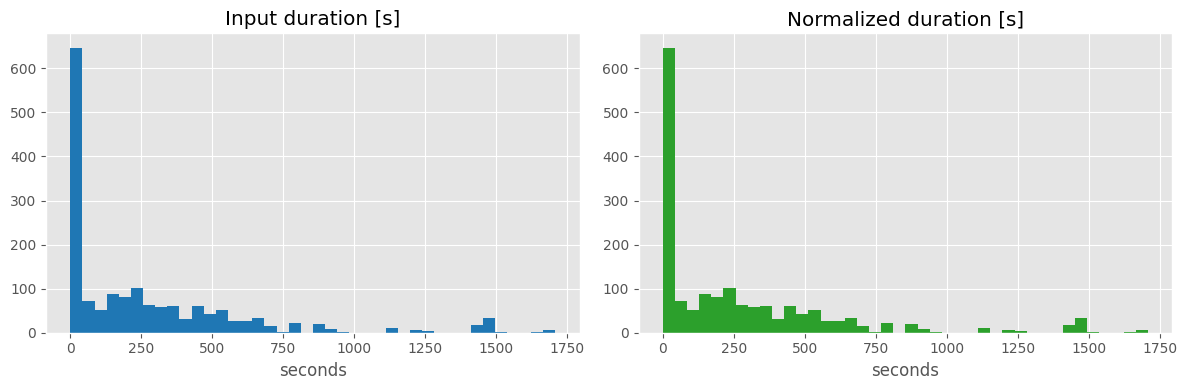

In [ ]:
if "process_status" not in result_df.columns:
    raise ValueError("result_df does not contain process_status")

ok_df = result_df[result_df["process_status"] == "ok"].copy()

print("\nSuccessful files:", len(ok_df))
print("Failed files:", len(result_df) - len(ok_df))

if len(ok_df) > 0:
    compare_cols = [
        "label",
        "input_fps",
        "normalized_fps",
        "input_width",
        "input_height",
        "normalized_width",
        "normalized_height",
        "input_duration_sec",
        "normalized_duration_sec",
    ]
    display(ok_df[compare_cols].head(10))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ok_df["input_duration_sec"].dropna().hist(bins=40, ax=axes[0], color="#1f77b4")
    axes[0].set_title("Input duration [s]")
    axes[0].set_xlabel("seconds")

    ok_df["normalized_duration_sec"].dropna().hist(bins=40, ax=axes[1], color="#2ca02c")
    axes[1].set_title("Normalized duration [s]")
    axes[1].set_xlabel("seconds")

    plt.tight_layout()
    plt.show()

In [ ]:
result_df.to_csv(OUTPUT_METADATA_CSV, index=False)

print("Saved metadata:", OUTPUT_METADATA_CSV)
print("Output videos root:", OUTPUT_DIR)

if len(ok_df) > 0:
    # Quick sanity check for a few successful outputs.
    sample_ok = ok_df.head(5)
    checks = []
    for p in sample_ok["normalized_video_path"]:
        vp = resolve_video_path(str(p), PROJECT_ROOT)
        checks.append((str(p), vp.exists()))
    display(pd.DataFrame(checks, columns=["normalized_video_path", "exists"]))

Saved metadata: D:\college\sem_mag_1\szum\merged_datasets\universal_metadata_topn_videos_normalized.csv
Output videos root: D:\college\sem_mag_1\szum\normalized_videos\topn_keepfps_224_gray


,normalized_video_path,exists
0,normalized_videos\topn_keepfps_224_gray\learn\...,False
1,normalized_videos\topn_keepfps_224_gray\teache...,False
2,normalized_videos\topn_keepfps_224_gray\like\m...,False
3,normalized_videos\topn_keepfps_224_gray\table\...,False
4,normalized_videos\topn_keepfps_224_gray\studen...,False
